
# Customer Churn Analysis Project

## Project Overview
This project focuses on predicting customer churn using Machine Learning techniques.  
Customer churn refers to customers leaving a company or stopping the use of a service.

### Objectives
- Perform Exploratory Data Analysis (EDA)
- Understand customer behavior patterns
- Build Machine Learning models for churn prediction
- Evaluate model performance
- Generate business insights and recommendations

### Dataset Information
The dataset contains:
- Customer demographics
- Banking information
- Account activity
- Customer churn status


In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


In [2]:
# Load Dataset

df = pd.read_csv('customer_data.csv')

# Display first 5 rows
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Dataset Information

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)


Dataset Shape: (10000, 12)

Columns:
 Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')


In [4]:
# Check Missing Values

df.isnull().sum()


customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


## Exploratory Data Analysis (EDA)

EDA helps us understand:
- Customer demographics
- Churn distribution
- Feature relationships
- Patterns affecting churn


In [5]:
# Churn Distribution

df['churn'].value_counts()


churn
0    7963
1    2037
Name: count, dtype: int64

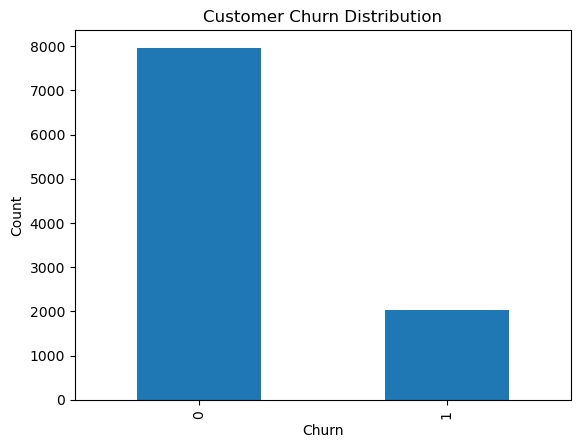

In [6]:
# Churn Visualization

df['churn'].value_counts().plot(kind='bar')
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()


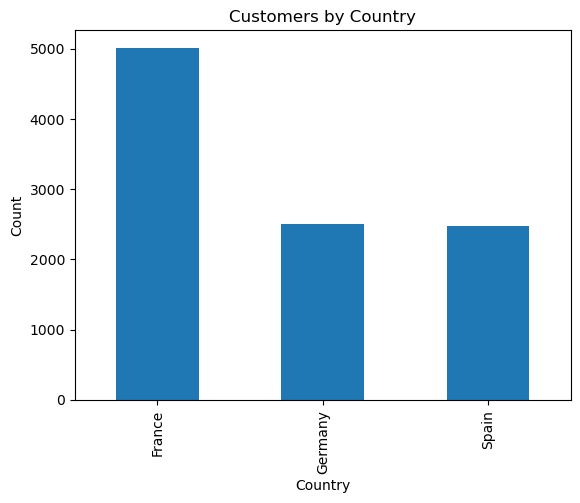

In [7]:
# Country-wise Customer Distribution

df['country'].value_counts().plot(kind='bar')
plt.title("Customers by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.show()


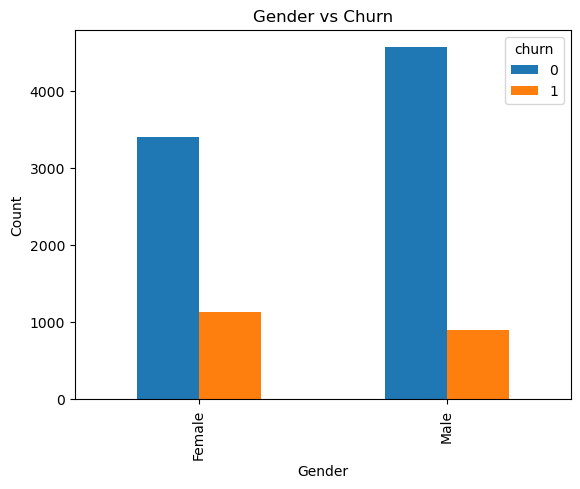

In [8]:
# Gender-wise Churn

pd.crosstab(df['gender'], df['churn']).plot(kind='bar')
plt.title("Gender vs Churn")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


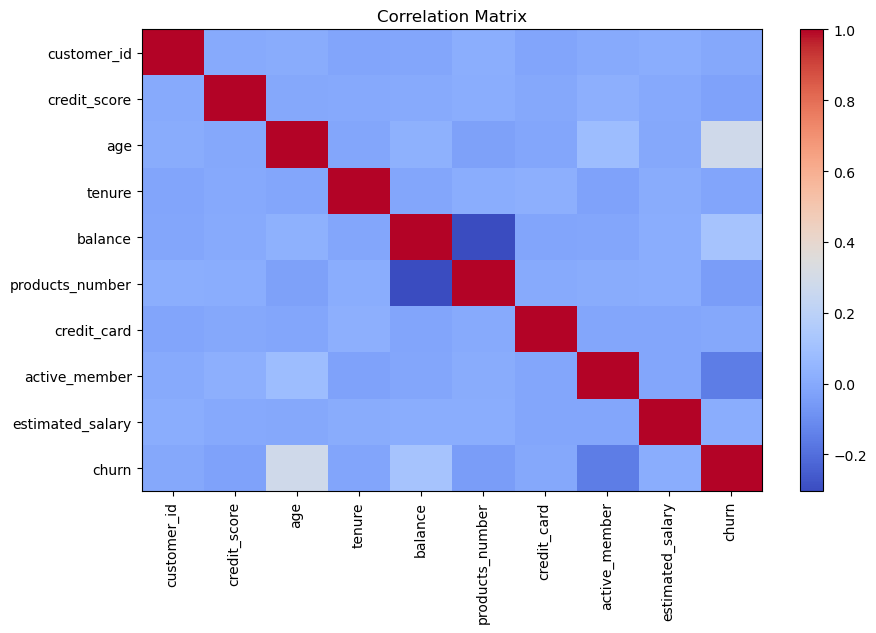

In [9]:
# Correlation Analysis

numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr = numeric_df.corr()

plt.figure(figsize=(10,6))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()



## Data Preprocessing

### Steps:
1. Encode categorical variables
2. Feature scaling
3. Train-test split


In [10]:
# Encoding Categorical Variables

encoder = LabelEncoder()

df['country'] = encoder.fit_transform(df['country'])
df['gender'] = encoder.fit_transform(df['gender'])

df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# Feature Selection

X = df.drop(['customer_id', 'churn'], axis=1)
y = df['churn']


In [12]:
# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (8000, 10)
Testing Data Shape: (2000, 10)


In [13]:
# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



# Model Building

We will train:
- Logistic Regression
- Random Forest Classifier
- XGBoost Classifier


In [14]:
# Logistic Regression Model

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))


Logistic Regression Accuracy: 0.8155
              precision    recall  f1-score   support

           0       0.83      0.97      0.89      1607
           1       0.60      0.18      0.28       393

    accuracy                           0.82      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.82      0.77      2000



In [15]:
# Random Forest Model

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))


Random Forest Accuracy: 0.8645
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.75      2000
weighted avg       0.85      0.86      0.85      2000



In [16]:
# XGBoost Model

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))


XGBoost Accuracy: 0.8555
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.68      0.49      0.57       393

    accuracy                           0.86      2000
   macro avg       0.78      0.72      0.74      2000
weighted avg       0.84      0.86      0.85      2000



In [17]:
# Compare Model Accuracy

models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, xgb_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracy
})

comparison


,Model,Accuracy
0,Logistic Regression,0.8155
1,Random Forest,0.8645
2,XGBoost,0.8555


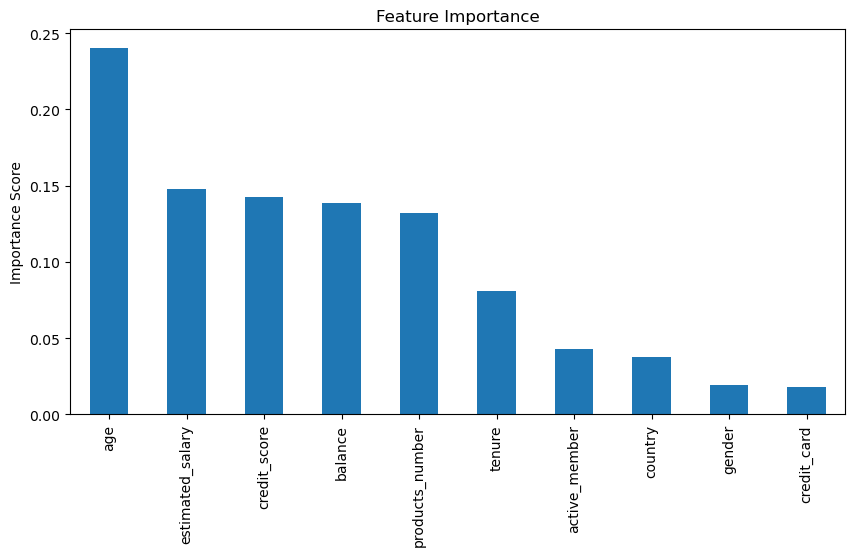

In [18]:
# Feature Importance using Random Forest

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.show()



# Business Insights

## Key Findings
- Older customers tend to churn more frequently.
- Active members are less likely to churn.
- Customers with fewer products show higher churn rates.
- Balance and credit score influence churn behavior.

## Business Recommendations
1. Improve customer engagement programs.
2. Provide personalized offers to high-risk customers.
3. Increase loyalty rewards for active members.
4. Monitor customers with low product usage.



# Conclusion

This project successfully analyzed customer churn behavior and developed machine learning models to predict customer churn.

### Achievements
- Performed complete EDA and preprocessing
- Built multiple ML models
- Compared model performance
- Generated actionable business insights

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
